In [ ]:
from datasets import load_dataset
# download the PII masked data from repo
data = load_dataset("ai4privacy/pii-masking-200k", data_files="english_pii_43k.jsonl", num_proc=4)

 Information about the dataset can be seen [here](https://huggingface.co/datasets/ai4privacy/pii-masking-200k/blob/main/README.md)

In [ ]:
print(data.keys())
print(len(data['train']))
print(data['train'][0])

dict_keys(['train'])
43501
{'source_text': "A student's assessment was found on device bearing IMEI: 06-184755-866851-3. The document falls under the various topics discussed in our Optimization curriculum. Can you please collect it?", 'target_text': "A student's assessment was found on device bearing IMEI: [PHONEIMEI]. The document falls under the various topics discussed in our [JOBAREA] curriculum. Can you please collect it?", 'privacy_mask': [{'value': '06-184755-866851-3', 'start': 57, 'end': 75, 'label': 'PHONEIMEI'}, {'value': 'Optimization', 'start': 138, 'end': 150, 'label': 'JOBAREA'}], 'span_labels': '[[0, 57, "O"], [57, 75, "PHONEIMEI"], [75, 138, "O"], [138, 150, "JOBAREA"], [150, 189, "O"]]', 'mbert_text_tokens': ['A', 'student', "'", 's', 'assessment', 'was', 'found', 'on', 'device', 'bearing', 'IM', '##E', '##I', ':', '06', '-', '1847', '##55', '-', '866', '##85', '##1', '-', '3', '.', 'The', 'document', 'falls', 'under', 'the', 'various', 'topics', 'discussed', 'in', '

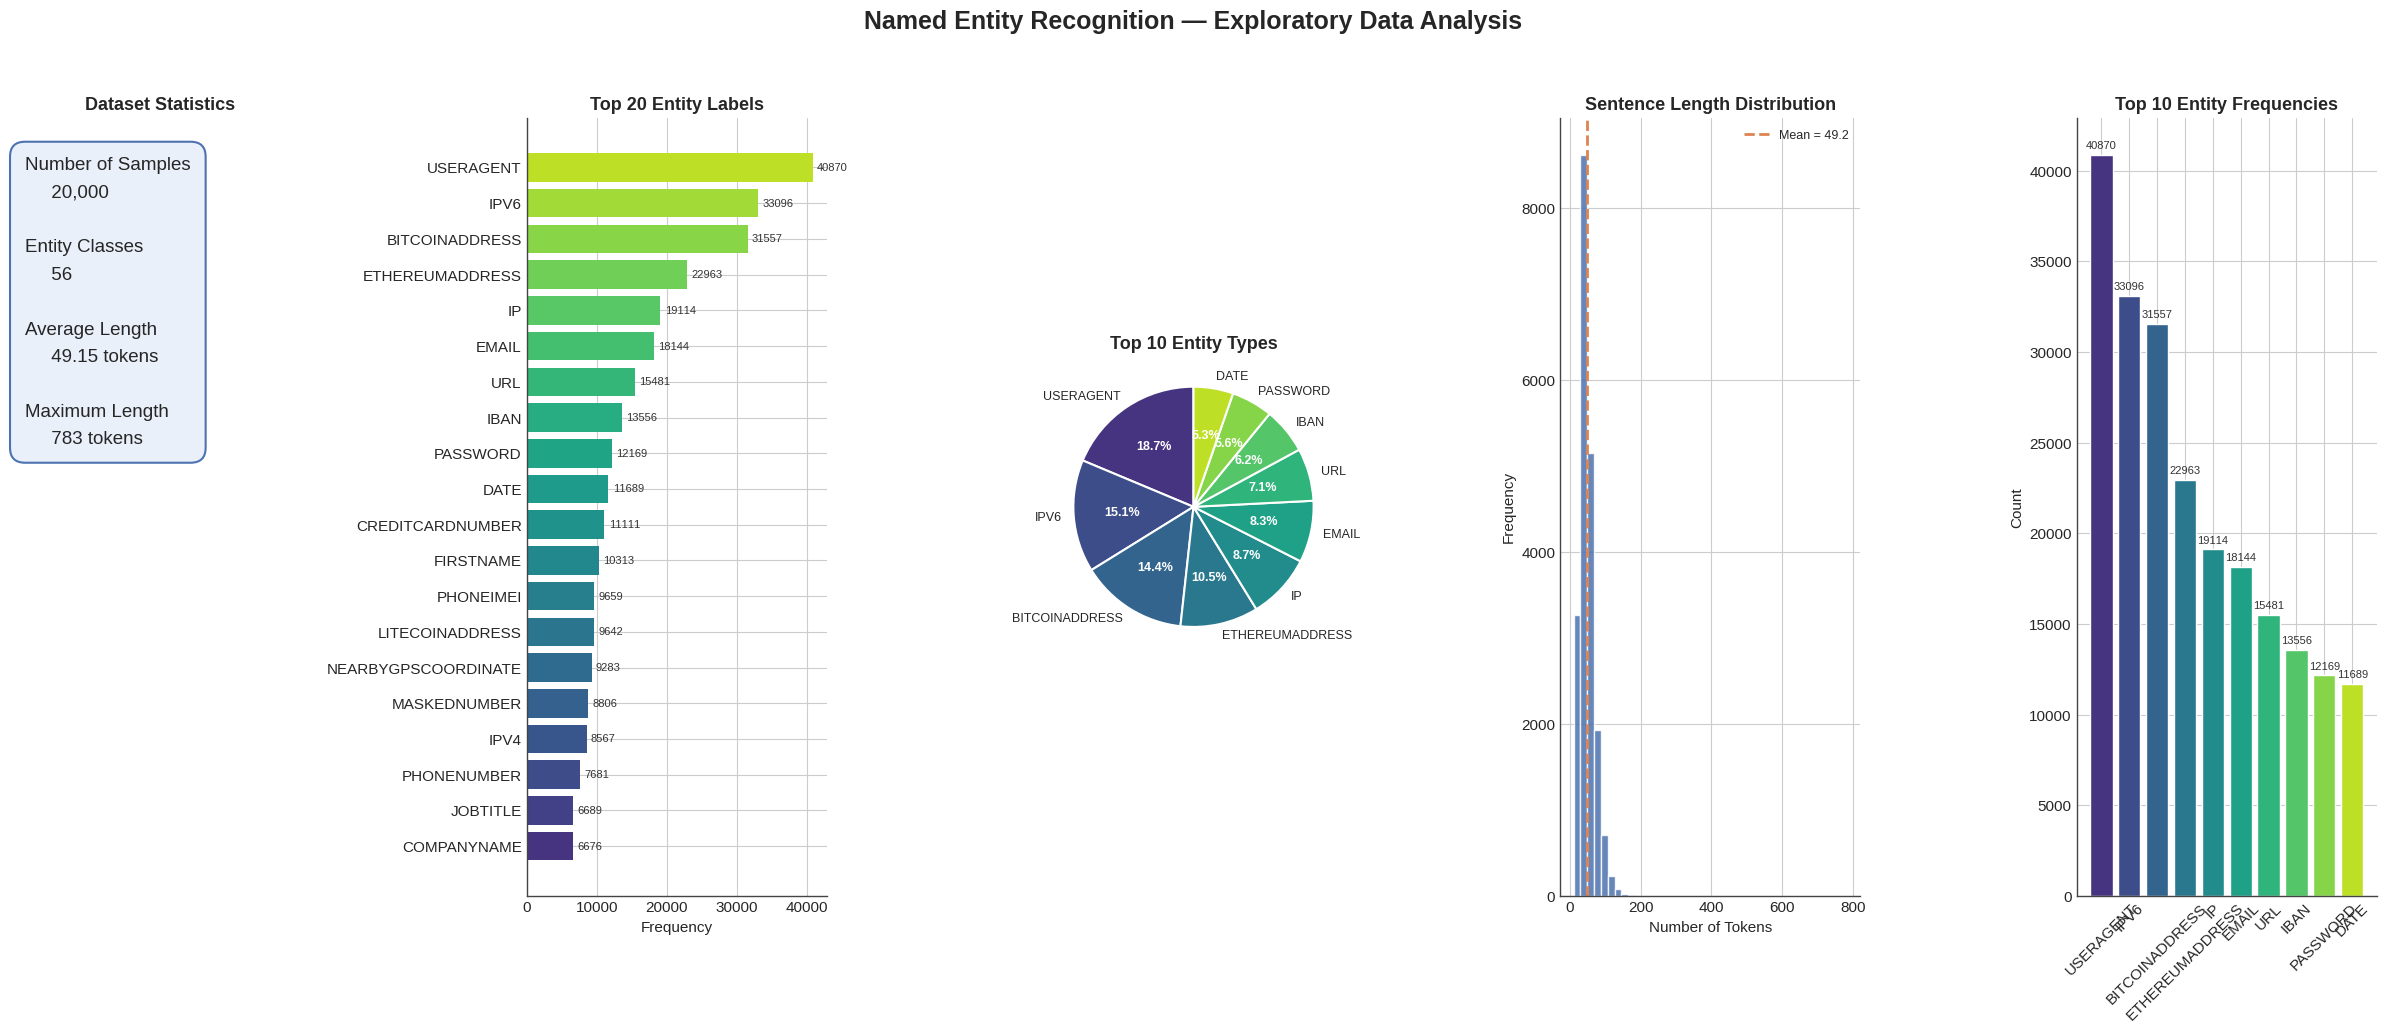

In [11]:
# EDA on the dataset
import matplotlib.pyplot as plt
from collections import Counter
import numpy as np

train_data = data["train"].select(range(20000))

num_samples = len(train_data)

entity_counter = Counter()
sentence_lengths = []

for sample in train_data:
    sentence_lengths.append(len(sample["mbert_text_tokens"]))

    for label in sample["mbert_bio_labels"]:
        if label != "O":
            entity = label.replace("B-", "").replace("I-", "")
            entity_counter[entity] += 1

num_entity_classes = len(entity_counter)

avg_sentence_length = np.mean(sentence_lengths)
max_sentence_length = np.max(sentence_lengths)

# top 20 entity counts
top20 = entity_counter.most_common(20)
top20_names = [x[0] for x in top20]
top20_counts = [x[1] for x in top20]

# top 10 entity counts
top10 = entity_counter.most_common(10)
top10_names = [x[0] for x in top10]
top10_counts = [x[1] for x in top10]

# ---- styling setup ----
plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams.update({
    "font.size": 11,
    "axes.titlesize": 13,
    "axes.titleweight": "bold",
    "axes.edgecolor": "#444444",
})

ACCENT = "#4C72B0"       # primary blue
ACCENT2 = "#DD8452"      # complementary orange
PALETTE = plt.cm.viridis(np.linspace(0.15, 0.9, 20))
PALETTE10 = plt.cm.viridis(np.linspace(0.15, 0.9, 10))

# plot
fig, axes = plt.subplots(1, 5, figsize=(24, 10))
fig.patch.set_facecolor("white")
fig.suptitle("Named Entity Recognition — Exploratory Data Analysis",
             fontsize=18, fontweight="bold", y=1.03)

# dataset summary
axes[0].axis("off")

summary = (
    f"Number of Samples\n     {num_samples:,}\n\n"
    f"Entity Classes\n     {num_entity_classes}\n\n"
    f"Average Length\n     {avg_sentence_length:.2f} tokens\n\n"
    f"Maximum Length\n     {max_sentence_length} tokens"
)

axes[0].text(0.05, 0.95, summary, fontsize=13.5, verticalalignment='top', linespacing=1.8,
    bbox=dict(boxstyle="round,pad=0.8", facecolor="#EAF0FA", edgecolor=ACCENT, linewidth=1.5))
axes[0].set_title("Dataset Statistics")

# top 20 entity labels
bars1 = axes[1].barh(top20_names[::-1], top20_counts[::-1], color=PALETTE)
axes[1].set_title("Top 20 Entity Labels")
axes[1].set_xlabel("Frequency")
axes[1].bar_label(bars1, padding=3, fontsize=8, color="#333333")
axes[1].spines[['top', 'right']].set_visible(False)

# pie chart
wedges, texts, autotexts = axes[2].pie(
    top10_counts, labels=top10_names, autopct='%1.1f%%', startangle=90,
    colors=PALETTE10, wedgeprops=dict(edgecolor='white', linewidth=1.5),
    textprops=dict(fontsize=9)
)
for at in autotexts:
    at.set_color("white")
    at.set_fontweight("bold")
axes[2].set_title("Top 10 Entity Types")

# sentence length
axes[3].hist(sentence_lengths, bins=40, color=ACCENT, edgecolor="white", alpha=0.85)
axes[3].axvline(avg_sentence_length, color=ACCENT2, linestyle="--", linewidth=2,
                label=f"Mean = {avg_sentence_length:.1f}")
axes[3].set_title("Sentence Length Distribution")
axes[3].set_xlabel("Number of Tokens")
axes[3].set_ylabel("Frequency")
axes[3].legend(frameon=False, fontsize=9)
axes[3].spines[['top', 'right']].set_visible(False)

# top 10 entity by frequency
bars2 = axes[4].bar(top10_names, top10_counts, color=PALETTE10, edgecolor="white")
axes[4].tick_params(axis='x', rotation=45)
axes[4].set_title("Top 10 Entity Frequencies")
axes[4].set_ylabel("Count")
axes[4].bar_label(bars2, padding=3, fontsize=8, color="#333333")
axes[4].spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.show()

In [ ]:
# creating label dict
all_labels = []

for sample in data["train"]:
    all_labels.extend(sample["mbert_bio_labels"])

unique_labels = sorted(list(set(all_labels)))

print("Number of labels:", len(unique_labels))
print(unique_labels)

Number of labels: 113
['B-ACCOUNTNAME', 'B-ACCOUNTNUMBER', 'B-AGE', 'B-AMOUNT', 'B-BIC', 'B-BITCOINADDRESS', 'B-BUILDINGNUMBER', 'B-CITY', 'B-COMPANYNAME', 'B-COUNTY', 'B-CREDITCARDCVV', 'B-CREDITCARDISSUER', 'B-CREDITCARDNUMBER', 'B-CURRENCY', 'B-CURRENCYCODE', 'B-CURRENCYNAME', 'B-CURRENCYSYMBOL', 'B-DATE', 'B-DOB', 'B-EMAIL', 'B-ETHEREUMADDRESS', 'B-EYECOLOR', 'B-FIRSTNAME', 'B-GENDER', 'B-HEIGHT', 'B-IBAN', 'B-IP', 'B-IPV4', 'B-IPV6', 'B-JOBAREA', 'B-JOBTITLE', 'B-JOBTYPE', 'B-LASTNAME', 'B-LITECOINADDRESS', 'B-MAC', 'B-MASKEDNUMBER', 'B-MIDDLENAME', 'B-NEARBYGPSCOORDINATE', 'B-ORDINALDIRECTION', 'B-PASSWORD', 'B-PHONEIMEI', 'B-PHONENUMBER', 'B-PIN', 'B-PREFIX', 'B-SECONDARYADDRESS', 'B-SEX', 'B-SSN', 'B-STATE', 'B-STREET', 'B-TIME', 'B-URL', 'B-USERAGENT', 'B-USERNAME', 'B-VEHICLEVIN', 'B-VEHICLEVRM', 'B-ZIPCODE', 'I-ACCOUNTNAME', 'I-ACCOUNTNUMBER', 'I-AGE', 'I-AMOUNT', 'I-BIC', 'I-BITCOINADDRESS', 'I-BUILDINGNUMBER', 'I-CITY', 'I-COMPANYNAME', 'I-COUNTY', 'I-CREDITCARDCVV', 'I-CR

In [ ]:
label2id = {
    label: idx
    for idx, label in enumerate(unique_labels)
}

id2label = {
    idx: label
    for label, idx in label2id.items()
}

print(label2id)

{'B-ACCOUNTNAME': 0, 'B-ACCOUNTNUMBER': 1, 'B-AGE': 2, 'B-AMOUNT': 3, 'B-BIC': 4, 'B-BITCOINADDRESS': 5, 'B-BUILDINGNUMBER': 6, 'B-CITY': 7, 'B-COMPANYNAME': 8, 'B-COUNTY': 9, 'B-CREDITCARDCVV': 10, 'B-CREDITCARDISSUER': 11, 'B-CREDITCARDNUMBER': 12, 'B-CURRENCY': 13, 'B-CURRENCYCODE': 14, 'B-CURRENCYNAME': 15, 'B-CURRENCYSYMBOL': 16, 'B-DATE': 17, 'B-DOB': 18, 'B-EMAIL': 19, 'B-ETHEREUMADDRESS': 20, 'B-EYECOLOR': 21, 'B-FIRSTNAME': 22, 'B-GENDER': 23, 'B-HEIGHT': 24, 'B-IBAN': 25, 'B-IP': 26, 'B-IPV4': 27, 'B-IPV6': 28, 'B-JOBAREA': 29, 'B-JOBTITLE': 30, 'B-JOBTYPE': 31, 'B-LASTNAME': 32, 'B-LITECOINADDRESS': 33, 'B-MAC': 34, 'B-MASKEDNUMBER': 35, 'B-MIDDLENAME': 36, 'B-NEARBYGPSCOORDINATE': 37, 'B-ORDINALDIRECTION': 38, 'B-PASSWORD': 39, 'B-PHONEIMEI': 40, 'B-PHONENUMBER': 41, 'B-PIN': 42, 'B-PREFIX': 43, 'B-SECONDARYADDRESS': 44, 'B-SEX': 45, 'B-SSN': 46, 'B-STATE': 47, 'B-STREET': 48, 'B-TIME': 49, 'B-URL': 50, 'B-USERAGENT': 51, 'B-USERNAME': 52, 'B-VEHICLEVIN': 53, 'B-VEHICLEVRM'

In [ ]:
# building dataset for model
from transformers import AutoTokenizer
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)
MODEL_NAME = "bert-base-multilingual-cased"
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

cuda


In [ ]:
# check a sample
sample = data["train"][0]

encoding = tokenizer(
    sample["mbert_text_tokens"],
    is_split_into_words=True,
    truncation=True,
    padding="max_length",
    max_length=128,
    return_tensors="pt"
)

print(tokenizer.convert_ids_to_tokens(encoding["input_ids"][0]))

['[CLS]', 'A', 'student', "'", 's', 'assessment', 'was', 'found', 'on', 'device', 'bearing', 'IM', '#', '#', 'E', '#', '#', 'I', ':', '06', '-', '1847', '#', '#', '55', '-', '866', '#', '#', '85', '#', '#', '1', '-', '3', '.', 'The', 'document', 'falls', 'under', 'the', 'various', 'topics', 'discussed', 'in', 'our', 'Op', '#', '#', 'tim', '##i', '#', '#', 'zati', '##on', 'curriculum', '.', 'Can', 'you', 'pl', '#', '#', 'ea', '##s', '#', '#', 'e', 'collect', 'it', '?', '[SEP]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]']


In [ ]:
print(encoding.word_ids())

[None, 0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 11, 11, 12, 12, 12, 13, 14, 15, 16, 17, 17, 17, 18, 19, 20, 20, 20, 21, 21, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 36, 36, 36, 37, 37, 37, 37, 38, 39, 40, 41, 42, 43, 43, 43, 43, 44, 44, 44, 45, 46, 47, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None]


In [ ]:
# preprocessing the dataset
from torch.utils.data import Dataset

class PIIDataset(Dataset):

    def __init__(self, dataset, tokenizer, label2id, max_length=128):

        self.dataset = dataset
        self.tokenizer = tokenizer
        self.label2id = label2id
        self.max_length = max_length

    def __len__(self):
        return len(self.dataset)

    def __getitem__(self, idx):

        sample = self.dataset[idx]

        tokens = sample["mbert_text_tokens"]

        labels = sample["mbert_bio_labels"]

        encoding = self.tokenizer(
            tokens,
            is_split_into_words=True,
            truncation=True,
            padding="max_length",
            max_length=self.max_length
        )

        word_ids = encoding.word_ids()

        label_ids = []

        previous_word = None

        for word_idx in word_ids:

            if word_idx is None:

                label_ids.append(-100)

            else:

                label_ids.append(
                    self.label2id[labels[word_idx]]
                )

        encoding["labels"] = label_ids

        return {
            "input_ids": torch.tensor(
                encoding["input_ids"],
                dtype=torch.long
            ),

            "attention_mask": torch.tensor(
                encoding["attention_mask"],
                dtype=torch.long
            ),

            "labels": torch.tensor(
                encoding["labels"],
                dtype=torch.long
            )
        }

In [ ]:
# testing for a small sample
train_dataset = PIIDataset(
    data["train"].select(range(5)),
    tokenizer,
    label2id
)
sample = train_dataset[0]

print(sample.keys())

dict_keys(['input_ids', 'attention_mask', 'labels'])


In [ ]:
print(sample["input_ids"].shape)
print(sample["labels"].shape)

torch.Size([128])
torch.Size([128])


In [ ]:
# create dataloader for training
from torch.utils.data import DataLoader

train_dataset = PIIDataset(
    data["train"].select(range(20000)),
    tokenizer,
    label2id
)

train_loader = DataLoader(
    train_dataset,
    batch_size=16,
    shuffle=True
)

In [ ]:
# verifying data loader
batch = next(iter(train_loader))

print(batch.keys())
print(batch["input_ids"].shape)
print(batch["attention_mask"].shape)
print(batch["labels"].shape)

dict_keys(['input_ids', 'attention_mask', 'labels'])
torch.Size([16, 128])
torch.Size([16, 128])
torch.Size([16, 128])


In [ ]:
# load the model to device
from transformers import AutoModelForTokenClassification

MODEL_NAME = "bert-base-multilingual-cased"

model = AutoModelForTokenClassification.from_pretrained(
    MODEL_NAME,
    num_labels=len(label2id),
    id2label=id2label,
    label2id=label2id
)

model.to(device)

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] BertForTokenClassification LOAD REPORT from: bert-base-multilingual-cased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
bert.pooler.dense.bias                     | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
bert.pooler.dense.weight                   | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params

BertForTokenClassification(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(119547, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-11): 12 x BertLayer(
          (attention): BertAttention(
            (self): BertSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,), eps=1e-12, e

In [ ]:
# taking one batch and test
batch = next(iter(train_loader))

batch = {k: v.to(device) for k, v in batch.items()}

In [ ]:
print(batch['input_ids'])

tensor([[  101, 12865, 11639,  ...,   108,   182,   102],
        [  101, 18830,   119,  ...,     0,     0,     0],
        [  101, 13554, 13145,  ...,   108,   186,   102],
        ...,
        [  101, 51555, 16235,  ...,     0,     0,     0],
        [  101, 57434, 34410,  ...,     0,     0,     0],
        [  101, 33671, 14943,  ...,     0,     0,     0]], device='cuda:0')


In [ ]:
# check the forward pass
outputs = model(input_ids=batch["input_ids"], attention_mask=batch["attention_mask"], labels=batch["labels"])

In [ ]:
print(outputs.keys())

odict_keys(['loss', 'logits'])


In [ ]:
print(outputs['loss'])

tensor(4.8020, device='cuda:0', grad_fn=<NllLossBackward0>)


In [ ]:
print(outputs.logits.shape)

torch.Size([16, 128, 113])


In [ ]:
# check the shape of predicted labels
predictions = torch.argmax(outputs.logits, dim=-1)

print(predictions.shape)

torch.Size([16, 128])


In [ ]:
pred_labels = [id2label[idx.item()] for idx in predictions[0]]

print(pred_labels[:30])

['B-NEARBYGPSCOORDINATE', 'I-CURRENCYCODE', 'O', 'I-TIME', 'I-SEX', 'I-CITY', 'I-CITY', 'I-CITY', 'I-CURRENCYCODE', 'I-CURRENCYCODE', 'I-CITY', 'I-CITY', 'I-CITY', 'B-TIME', 'I-CITY', 'I-MIDDLENAME', 'I-CITY', 'I-CITY', 'B-CURRENCYCODE', 'I-CITY', 'I-CITY', 'B-CURRENCYCODE', 'B-IPV6', 'I-ORDINALDIRECTION', 'I-EYECOLOR', 'I-ZIPCODE', 'B-MAC', 'B-USERAGENT', 'I-NEARBYGPSCOORDINATE', 'I-STREET']


In [ ]:
! pip install transformers

In [ ]:
# starting the training loop
from transformers import get_linear_schedule_with_warmup
from torch.optim import AdamW

optimizer = AdamW(model.parameters(), lr=2e-5, weight_decay=0.01)

epochs = 3

total_steps = len(train_loader) * epochs

scheduler = get_linear_schedule_with_warmup(optimizer, num_warmup_steps=0, num_training_steps=total_steps)

In [ ]:
# mixed precision for low memoy footprint
from torch.cuda.amp import autocast, GradScaler

scaler = GradScaler()

/tmp/ipykernel_715/427387975.py:4: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler()


In [ ]:
from tqdm.auto import tqdm

model.train()

for epoch in range(epochs):

    total_loss = 0
    progress = tqdm(train_loader)

    for batch in progress:
        batch = {k: v.to(device) for k, v in batch.items()}
        optimizer.zero_grad()

        with autocast():
            outputs = model(input_ids=batch["input_ids"], attention_mask=batch["attention_mask"], labels=batch["labels"])
            loss = outputs.loss
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()
        scheduler.step()
        total_loss += loss.item()
        progress.set_description(f"Epoch {epoch+1}")
        progress.set_postfix(loss=loss.item())
    avg_loss = total_loss / len(train_loader)

    print(f"\nEpoch {epoch+1}")
    print(f"Average Loss : {avg_loss:.4f}")

  0%|          | 0/1250 [00:00<?, ?it/s]

/tmp/ipykernel_715/3127950196.py:14: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
/tmp/ipykernel_715/3127950196.py:20: UserWarning: Detected call of `lr_scheduler.step()` before `optimizer.step()`. In PyTorch 1.1.0 and later, you should call them in the opposite order: `optimizer.step()` before `lr_scheduler.step()`.  Failure to do this will result in PyTorch skipping the first value of the learning rate schedule. See more details at https://pytorch.org/docs/stable/optim.html#how-to-adjust-learning-rate
  scheduler.step()



Epoch 1
Average Loss : 0.5476


  0%|          | 0/1250 [00:00<?, ?it/s]


Epoch 2
Average Loss : 0.1691


  0%|          | 0/1250 [00:00<?, ?it/s]


Epoch 3
Average Loss : 0.1248


In [ ]:
# save the model
SAVE_PATH = "pii_ner_model"

model.save_pretrained(SAVE_PATH)
tokenizer.save_pretrained(SAVE_PATH)

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

('pii_ner_model/tokenizer_config.json', 'pii_ner_model/tokenizer.json')

In [ ]:
# save label mappings
import json

with open(f"{SAVE_PATH}/label2id.json", "w") as f:
    json.dump(label2id, f, indent=4)

with open(f"{SAVE_PATH}/id2label.json", "w") as f:
    json.dump(id2label, f, indent=4)

In [ ]:
# download the folder
from google.colab import files
import shutil

shutil.make_archive("pii_ner_model", "zip", SAVE_PATH)

files.download("/content/pii_ner_model.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# create a validation set
val_dataset = PIIDataset(data["train"].select(range(20000, 25000)), tokenizer, label2id)
val_loader = DataLoader(val_dataset, batch_size=16, shuffle=False)

In [ ]:
!pip install seqeval

In [ ]:
from seqeval.metrics import classification_report, f1_score, precision_score, recall_score

In [ ]:
def evaluate(model, dataloader, id2label, device):
    model.eval()
    true_labels = []
    pred_labels = []
    with torch.no_grad():

        for batch in tqdm(dataloader):
            batch = {k: v.to(device) for k, v in batch.items()}
            outputs = model(input_ids=batch["input_ids"], attention_mask=batch["attention_mask"])
            predictions = torch.argmax(outputs.logits, dim=-1)
            labels = batch["labels"]

            for pred, label in zip(predictions, labels):
                true_sequence = []
                pred_sequence = []
                for p, l in zip(pred.cpu().numpy(), label.cpu().numpy()):
                    if l == -100:
                        continue
                    true_sequence.append(id2label[int(l)])
                    pred_sequence.append(id2label[int(p)])

                true_labels.append(true_sequence)
                pred_labels.append(pred_sequence)

    print("\nPrecision :", precision_score(true_labels, pred_labels))
    print("Recall    :", recall_score(true_labels, pred_labels))
    print("F1 Score  :", f1_score(true_labels, pred_labels))

    print("\nClassification Report\n")

    print(classification_report(true_labels, pred_labels))

    return true_labels, pred_labels

In [ ]:
# evaluation of model
true_labels, pred_labels = evaluate(model, val_loader, id2label, device)

  0%|          | 0/313 [00:00<?, ?it/s]


Precision : 0.8726972274925026
Recall    : 0.9001325673884224
F1 Score  : 0.886202610316967

Classification Report

                     precision    recall  f1-score   support

        ACCOUNTNAME       0.96      0.97      0.97       331
      ACCOUNTNUMBER       0.95      0.96      0.96       357
                AGE       0.82      0.83      0.83       266
             AMOUNT       0.89      0.93      0.91       560
                BIC       0.87      0.91      0.89        97
     BITCOINADDRESS       0.90      0.97      0.93       241
     BUILDINGNUMBER       0.87      0.87      0.87       321
               CITY       0.90      0.89      0.90       314
        COMPANYNAME       0.97      0.99      0.98       268
             COUNTY       0.89      0.95      0.92       308
      CREDITCARDCVV       0.86      0.89      0.88       103
   CREDITCARDISSUER       0.95      0.98      0.96       178
   CREDITCARDNUMBER       0.79      0.92      0.85       291
           CURRENCY       0.

### Analysis of Evaluation Results

The model achieved a **micro-averaged F1 score of 0.89**, with a **precision of 0.87** and **recall of 0.90**. This indicates a strong overall performance in identifying PII entities.

**Key observations from the classification report:**

*   **Strong Performance:** The model performed exceptionally well on entities like `COMPANYNAME`, `EMAIL`, `PHONEIMEI`, `PHONENUMBER`, `NEARBYGPSCOORDINATE`, `VEHICLEVIN`, and `VEHICLEVRM`, consistently achieving F1 scores of 0.95 or higher. This suggests these entity types are well-represented and distinct in the training data.

*   **Areas for Improvement:**
    *   `CURRENCYNAME` has an F1 score of 0.00, indicating that the model failed to correctly identify any instances of this entity. This is due to a very small number of examples in the training set or significant ambiguity.
    *   `IP` also shows very low performance (F1: 0.01), suggesting difficulty in distinguishing IP addresses from other tokens as  IP addresses suffer from radical sub-token fragmentation and strict structural ambiguity during tokenization as BERT uses wordpiece tokenizer.
    *   `CURRENCY` (F1: 0.67), `DOB` (F1: 0.55), `MIDDLENAME` (F1: 0.61), and `PIN` (F1: 0.65) show moderate to low F1 scores, indicating that these might be challenging entities for the model to predict accurately. This is due to their varied formats, contextual ambiguity and limited training data for these specific types.

### Business Insights: Preventing PII Leakage to AI Models

Protecting Personally Identifiable Information (PII) is essential before sending data to AI models. This project shows that how local AI can automatically detect and mask many sensitive entities, reducing the risk of exposing private information.

**Key Business Insights:**

* Automatically redact sensitive data such as names, emails, phone numbers, account numbers, and credit card details before sharing data with AI systems.
* Train AI models only on sanitized datasets to prevent them from learning or exposing sensitive information.
* Secure the AI pipeline with encryption, access control, and by collecting only the data that is necessary.
* AI outputs to ensure no confidential information is accidentally leaked.
